# 03 — Training the inverse model

**What this notebook is for.** Notebook 02 built the ruler: a classical fit that
reaches **0.034 nm of thickness** on films whose physics it models exactly, at
**8.44 seconds per film**. This notebook covers what happened when a network was
asked to do the same job — DTFM-038 through DTFM-047, and DTFM-070.

The short version is that the project spent two days tuning the wrong variable.

| what changed | what it bought |
|---|---|
| training 15× longer (8k → 120k steps) | ~5× |
| **changing the loss** (MSE → Gaussian NLL) | **~2×, and convergence** |
| architecture and learning rate | ~1.3× |
| ensembling five seeds | ~1.33× |

Every number below was measured across **five seeds** unless it says otherwise.
That is not caution for its own sake: this project twice believed a result that
one seed had invented, and both times the correction went the other way.

Nothing here computes physics. Every number comes from `src/`, or is quoted from
a run that is named.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from src import dataset as ds
from src import generate as gen
from src import losses as ls
from src import models
from src import training as tr

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})

WAVELENGTHS = np.linspace(400.0, 800.0, 200)
PRIOR = gen.Prior()
torch.manual_seed(0)
print(f"prior: {PRIOR.thickness_nm[0]:.0f}-{PRIOR.thickness_nm[1]:.0f} nm of thickness, "
      f"log-uniform; n(lambda) Cauchy A in {PRIOR.cauchy_a}, B in {PRIOR.cauchy_b}")

prior: 20-2000 nm of thickness, log-uniform; n(lambda) Cauchy A in (1.4, 1.55), B in (0.002, 0.012)


## 1. What the network is actually asked to do

400 numbers in, 3 numbers out.

The 400 are 200 wavelengths × two ellipsometric angles, Ψ and Δ. The 3 are the
film's thickness and the two Cauchy coefficients describing how it bends light.

The coefficients are not incidental. The network is never told them, and a
thicker film with a lower index produces nearly the spectrum of a thinner film
with a higher one. Separating those is the whole difficulty — DTFM-034 measured
the correlation between thickness and index at **above 0.99 past 700 nm**.

observed (512, 400)  ->  targets (512, 3)
films per thickness band: 20-100 nm: 152, 100-700: 223, 700-2000: 137


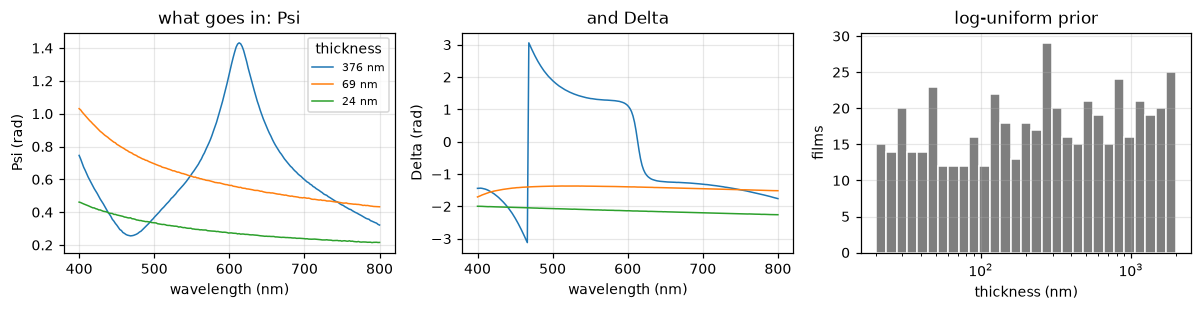

In [2]:
batch = ds.sample_batch(512, WAVELENGTHS, np.random.default_rng(0), prior=PRIOR)
psi, delta = ls.split_psi_delta(batch.observed)
thickness = batch.targets[:, 0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
for i, colour in zip((0, 1, 2), ("tab:blue", "tab:orange", "tab:green"), strict=True):
    axes[0].plot(WAVELENGTHS, psi[i], color=colour, lw=1,
                 label=f"{thickness[i]:.0f} nm")
    axes[1].plot(WAVELENGTHS, delta[i], color=colour, lw=1)
axes[0].set(xlabel="wavelength (nm)", ylabel="Psi (rad)", title="what goes in: Psi")
axes[1].set(xlabel="wavelength (nm)", ylabel="Delta (rad)", title="and Delta")
axes[0].legend(title="thickness", fontsize=7)

axes[2].hist(thickness, bins=np.logspace(np.log10(20), np.log10(2000), 30),
             color="tab:grey", edgecolor="white")
axes[2].set(xscale="log", xlabel="thickness (nm)", ylabel="films",
            title="log-uniform prior")
fig.tight_layout()

print(f"observed {tuple(batch.observed.shape)}  ->  targets {tuple(batch.targets.shape)}")
print(f"films per thickness band: "
      f"20-100 nm: {int(((thickness>=20)&(thickness<100)).sum())}, "
      f"100-700: {int(((thickness>=100)&(thickness<700)).sum())}, "
      f"700-2000: {int((thickness>=700).sum())}")

The prior is **log-uniform**, which is why the three bands hold comparable
numbers of films despite spanning very different widths. Uniform sampling would
have put almost everything above 700 nm and left the thin regime — the one this
project is written about — with too few films to have a meaningful median.

## 2. Two architectures, and why both were built

§7.2 asks for an MLP and a 1D CNN. The MLP receives the 400 inputs as an
unordered vector and has to *learn* that wavelength 51 sits beside wavelength 52.
A convolution is told: it slides a 7-wavelength window along the spectrum and
finds a fringe pattern wherever it occurs, spending capacity on the shape rather
than on the position.

The reshape is load-bearing. 400 inputs become **200 wavelengths × 2 channels**,
because Ψ[i] and Δ[i] are the same wavelength. A 1×400 layout would let the
kernel straddle index 200 and mix the phase near 800 nm with the amplitude near
400 nm — meaningless, and it would train happily while doing it.

In [3]:
for name, settings in (("MLP", {"architecture": "mlp", "width": 512, "depth": 3}),
                       ("CNN", {"architecture": "cnn", "channels": 64, "kernel": 7,
                                "depth": 3})):
    model = models.build_model(settings | {"uncertainty": True}, prior=PRIOR)
    shapes = [tuple(p.shape) for n, p in model.named_parameters() if p.dim() > 1]
    print(f"{name:4} {model.parameter_count:>9,} parameters   {shapes}")

MLP    733,702 parameters   [(512, 400), (512, 512), (512, 512), (3, 512), (3, 512)]
CNN    469,830 parameters   [(64, 2, 7), (64, 64, 7), (64, 64, 7), (256, 1600), (3, 256), (3, 256)]


## 3. Training, on a scale that fits in a notebook

The runs this notebook narrates took 96,000 steps each. The mechanism is visible
in 400, which is what runs below — the loss falls, and that is all this cell is
claiming. The accuracy numbers come later and come from the real runs.

Note the loss is computed in **cube units**, not nanometres. Thickness spans
1980 nm of thickness while the Cauchy coefficient B spans 0.01; summed in
physical units the thickness term would outweigh B by five orders of magnitude
and B would never be learned.

loss 0.058 -> -1.426 in 400 steps
the real runs continue this for 96,000


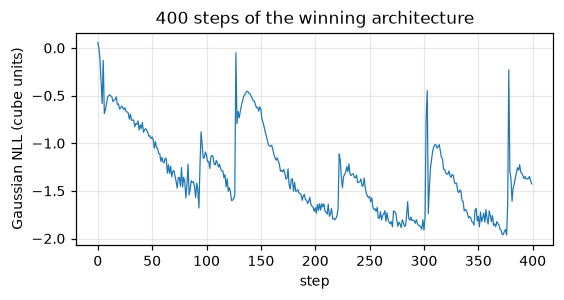

In [4]:
config = tr.RunConfig(architecture="cnn", channels=64, kernel=7, depth=3,
                      steps=400, batch=256, uncertainty=True)
model = models.build_model(config.model_settings(), prior=PRIOR)
scaler = model.scale_theta
optimiser = torch.optim.Adam(model.parameters(), lr=config.lr)
rng = np.random.default_rng(0)

curve = []
for _ in range(config.steps):
    b = ds.sample_batch(config.batch, WAVELENGTHS, rng, prior=PRIOR)
    optimiser.zero_grad()
    theta, log_var = model(b.observed.float())
    loss, _ = ls.total_loss(theta, b.targets, b.observed, scaler, log_var=log_var)
    loss.backward()
    optimiser.step()
    curve.append(float(loss.detach()))

fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.plot(curve, lw=0.8, color="tab:blue")
ax.set(xlabel="step", ylabel="Gaussian NLL (cube units)",
       title="400 steps of the winning architecture")
fig.tight_layout()
print(f"loss {curve[0]:.3f} -> {curve[-1]:.3f} in {config.steps} steps")
print("the real runs continue this for 96,000")

## 4. The finding that mattered most: the loss

Every run in this project up to DTFM-042 minimised **mean squared error**. That
choice was never examined. Replacing it with **Gaussian negative log-likelihood**
did more than every architecture and schedule change combined.

$$L_{\mathrm{NLL}} = \tfrac{1}{2}\sum_k \left[
\frac{(\hat\theta_k-\theta_k)^2}{\hat\sigma_k^2}
+ \log\hat\sigma_k^2\right]$$

The first term rewards a large σ̂ — dividing by something big makes any error look
small. The second punishes it. The minimum sits where σ̂² equals the squared error
the network actually makes, so the only way to score well is to state an
uncertainty that matches reality.

That also makes it **weighted regression in which the model sets its own
weights**: films it cannot fit get a large σ̂ and are down-weighted, so capacity
goes where it can be used. MSE forces equal effort onto films that are physically
ambiguous.

**Measured**, same network, same length, 4,000 steps:

| loss | median | RMSE | p95 |
|---|---|---|---|
| MSE | 7.038 | 14.886 | 32.995 |
| **Gaussian NLL** | **1.445** | **7.742** | **16.724** |

nm of thickness. Every statistic improved, so it is not a robustness artefact.

For scale: the best MSE model in the 271-run history needed **120,000 steps** to
reach 1.124 nm of thickness. The loss was worth more than thirty times the
compute. It also made training *converge* — under MSE the loss was still falling
by 37–54% when runs stopped; under NLL it is flat by 24,000 steps — and made it
**repeatable**, with seed spreads dropping from 2–23% to 0.8–3.6%.

## 5. A negative result: the physics term does nothing

§7.3 adds a reconstruction term that pushes the network's own guess back through
the differentiable transfer matrix and compares the result against the spectrum
it started from:

$$L = L_{\mathrm{NLL}} + \lambda_{\mathrm{recon}}\,
\lVert f(\hat\theta) - R_{\mathrm{obs}}\rVert^2$$

The board calls this term *"what makes the project scientific ML rather than
generic regression — it is not optional."* DTFM-045 ablated it over 75 runs:
five weights, three training lengths, five seeds.

| λ_recon | 24k | 48k | 96k |
|---|---|---|---|
| 0 | 0.705 | 0.656 | 0.617 |
| 1e-4 | 0.700 | 0.645 | 0.613 |
| 1e-3 | 0.702 | 0.654 | 0.624 |
| 3e-3 | 0.713 | 0.657 | 0.614 |
| 1e-2 | 0.711 | 0.653 | 0.611 |

nm of thickness. **Not one value is separable from the control** (Welch,
p = 0.22–0.78); the gaps are under 1% of the baseline, inside seed noise.

The loss breakdown says why, and the cell below reproduces the mechanism.

In [5]:
reconstruct = ls.Reconstructor(WAVELENGTHS, prior=PRIOR)
truth = batch.targets[:32].float()

at_truth = ls.reconstruction_loss(truth, batch.observed[:32], reconstruct)
displaced = truth.clone()
displaced[:, 0] += 5.0
at_displaced = ls.reconstruction_loss(displaced, batch.observed[:32], reconstruct)

print(f"L_recon at the true parameters   {float(at_truth):.5f}")
print(f"L_recon with +5 nm of thickness  {float(at_displaced):.5f}")
print()
print("It is a real signal -- and it costs nothing to satisfy. In the 96,000-step")
print("runs it collapses from ~2 to ~0.01 on its own, and lambda * L_recon then")
print("contributes 0.00% of a total whose fit term is about 4.8. Accurate")
print("parameters reconstruct the spectrum for free.")

L_recon at the true parameters   0.00896
L_recon with +5 nm of thickness  0.06177

It is a real signal -- and it costs nothing to satisfy. In the 96,000-step
runs it collapses from ~2 to ~0.01 on its own, and lambda * L_recon then
contributes 0.00% of a total whose fit term is about 4.8. Accurate
parameters reconstruct the spectrum for free.


**The floor is not the network's fault.** θ̂ has three components; a film also
carries 0–4 nm of thickness of surface roughness (§4.5) and the observation
carries instrument noise. Neither is predicted, so `f(θ̂)` cannot match an
observation even at the true parameters.

**So is the term worthless?** For accuracy on in-distribution data, on this
evidence, yes — with two million perfectly-labelled films the labels already
encode the physics. Its remaining value is out-of-distribution robustness
(DTFM-053/054) and as an **inference-time self-check**: the residual is
computable on a real wafer where nobody knows the true thickness, which a plain
regressor cannot do at all. That works whether or not the term was ever in the
loss.

Recording a negative result against the project's own spec is the point. A
notebook that only showed what worked would be advertising.

## 6. Against the ruler

DTFM-044 scores the network through the *same* function, on the *same* films,
with the *same* noise draws as the classical fit. Two test sets, because §4.5
gives every training film 0–4 nm of thickness of roughness and the classical
baseline's cases have none.

roughness moves Delta by up to 0.391 rad
the instrument noise is 0.0010 rad -- a factor of 391


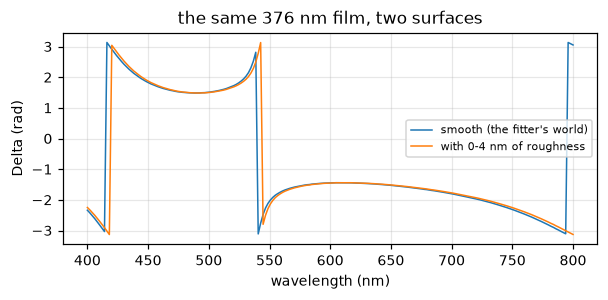

In [6]:
from src import evaluate as ev

smooth = ev.make_cases(3, seed=0, prior=PRIOR, roughness=False)
rough = ev.make_cases(3, seed=0, prior=PRIOR, roughness=True)

fig, ax = plt.subplots(figsize=(5.6, 2.8))
p_s, d_s = ls.split_psi_delta(torch.tensor(smooth[0].observed)[None, :])
p_r, d_r = ls.split_psi_delta(torch.tensor(rough[0].observed)[None, :])
ax.plot(WAVELENGTHS, d_s[0], lw=1, label="smooth (the fitter's world)")
ax.plot(WAVELENGTHS, d_r[0], lw=1, label="with 0-4 nm of roughness")
ax.set(xlabel="wavelength (nm)", ylabel="Delta (rad)",
       title=f"the same {smooth[0].thickness_nm:.0f} nm film, two surfaces")
ax.legend(fontsize=7)
fig.tight_layout()

gap = float(ls.wrapped_difference(d_s, d_r).abs().max())
print(f"roughness moves Delta by up to {gap:.3f} rad")
print(f"the instrument noise is {smooth[0].sigma:.4f} rad "
      f"-- a factor of {gap / smooth[0].sigma:.0f}")

**The result, and it goes both ways.**

| | classical | learned |
|---|---|---|
| **smooth films** | **0.025** | 0.856 |
| **rough films** | 1.014 | **0.736** |
| failures >1 nm, rough | 51.2% | **37.5%** |
| seconds per film | 10.1 | **0.0011** |

nm of thickness, one seed, 80 cases per set.

On smooth films the classical fit is **34× better and never fails** — its model is
exactly right. On rough films it gets **40× worse** and fails on half of them,
because it has three parameters and roughness is not one of them. The network is
unchanged between the two.

> The classical fit is 34× better when its model is right, and 1.4× worse when it
> is not. The network is insensitive to which.

That is a comparison of *assumptions*, not of algorithms. A real wafer has
roughness, interfacial oxide and non-uniformity that no three-parameter model
captures, and the classical 0.025 nm of thickness is conditional on a perfect
model in a way the network's 0.736 is not.

Per **§3a**, no novelty is claimed for the speed column: it is amortised training
cost paid once, stated rather than argued from.

## 7. Five models instead of one

DTFM-047 averages five seeds and splits the variance into the two things it is
made of:

$$\mathrm{var} =
\underbrace{\tfrac{1}{M}\sum\hat\sigma_m^2}_{\text{aleatoric}}
+ \underbrace{\tfrac{1}{M}\sum\hat\theta_m^2 - \bar\theta^2}_{\text{epistemic}}$$

**Aleatoric** is the film being genuinely ambiguous; irreducible, and it says
*measure the film differently*. **Epistemic** is the models disagreeing — the one
thing a single network cannot report about itself, since a confidently wrong
model returns a small σ̂ with nothing to contradict it. Reducible, and it says
*train a better model*.

In [7]:
members = [models.build_model({"architecture": "cnn", "channels": 64, "kernel": 7,
                              "depth": 3, "uncertainty": True}, prior=PRIOR)
           for _ in range(5)]
parts = models.Ensemble(members).decompose(batch.observed[:64].float())

print("on UNTRAINED members, to show the decomposition rather than a result:")
for key in ("aleatoric", "epistemic", "total"):
    print(f"  {key:10} median {float(parts[key][:, 0].median()):8.2f} nm of thickness")
closes = torch.allclose(parts["total"] ** 2,
                        parts["aleatoric"] ** 2 + parts["epistemic"] ** 2, atol=1e-6)
print(f"  identity holds: {closes}")

on UNTRAINED members, to show the decomposition rather than a result:
  aleatoric  median  1984.32 nm of thickness
  epistemic  median     8.35 nm of thickness
  total      median  1984.34 nm of thickness
  identity holds: True


**Measured on the five trained seeds** (2000 unseen films):

| | |
|---|---|
| ensemble | **0.368 nm of thickness** — the project's best |
| single members | 0.489 ± 0.022 |
| aleatoric (median) | 1.806 |
| epistemic (median) | 0.275 |

Aleatoric dominates epistemic by **6.6×**: the models agree with each other far
more than the films are ambiguous, so training more of the same will not help.

**And the calibration is not fixed.** Coverage within 1σ̂ goes from 0.943 for a
single model to **0.995** for the ensemble, against 0.683 for a calibrated
Gaussian — the total is aleatoric *plus* something, not a correction to it. The
over-dispersion is real rather than a heavy-tail artefact: RMS σ̂ is 2.05× RMS
error on the very measure NLL optimises.

σ̂ is honest in *direction* — it correlates with the error at 0.809 — and wrong in
*magnitude* by a factor of two to three. Fixing that is DTFM-048 to DTFM-050,
which is where this project's headline claim gets decided.

## 8. Where this leaves the project

```
0.368 nm of thickness   ensemble of five CNNs, 96,000 steps, NLL
0.034                   classical fit, when its model is right
```

**A factor of 11 apart** — down from 176× three days ago.

The remaining gap is not a physics limit. DTFM-034's Cramér–Rao bound says the
information is present in the spectrum, and the classical fit extracts nearly all
of it when its model holds. The network does not. That is a model limitation,
which is the better kind to have.

**What is honestly still open:**

- σ̂ is over-dispersed 2–3×, so *calibrated uncertainty* — the project's headline
  claim — is not yet demonstrated. DTFM-048–050.
- Everything here is **in-distribution**: films drawn from the prior the network
  trained on. DTFM-053/054 probe outside it, and those numbers will be worse.
- The thick regime carries most of the error, 1.9–2.5 nm of thickness with 70–90%
  of films wrong by more than 1 nm. That matches DTFM-034's ρ(thickness, index)
  above 0.99 past 700 nm, and it is DTFM-055's job to characterise rather than a
  detail to mention.
- The most useful thing the network can do may not be replacing the classical fit
  at all, but routing to it: answer the easy films in microseconds, hand over the
  uncertain ones. That is DTFM-057, and it needs a σ̂ that can be trusted.